# Optimization from Scratch in PyTorch
### Logistic regression with mini-batch SGD, numerical stability, L1 sparsity, and optimizer behaviour on convex vs. non-convex landscapes

This notebook implements the core pieces of model training **by hand, using only PyTorch primitives**, and studies how they behave:

1. **A numerically stable binary cross-entropy loss**
2. **Logistic regression** with configurable weight initialisation
3. **A mini-batch SGD training loop** with per-epoch metrics and per-step parameter history
4. **A hyperparameter study**: a learning rate × batch size grid on SST-2 sentiment classification
5. **L1 regularisation**: why plain (sub)gradient SGD does *not* produce sparse weights, and how a proximal step does
6. **Optimizers from scratch** (GD, Momentum, AdaGrad, Adam) on a convex bowl and on the non-convex Six-hump Camel function

**Data:** [SST-2](https://huggingface.co/datasets/SetFit/sst2), binary movie-review sentiment: 6,920 training and 872 validation sentences.

## 0. Setup

In [1]:
import re, random
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

## 1. Data: cleaning and bag-of-words features

Preprocessing is deliberately minimal: lowercase the text, split hyphenated words, keep letters, digits and basic punctuation, and collapse whitespace. Features are **bag-of-words counts over the 10,000 most frequent training tokens**. The vocabulary is built on the training split only, so no validation information leaks into the features.

In [2]:
sst2 = load_dataset("SetFit/sst2")
data_train, data_val = sst2["train"], sst2["validation"]

def clean_text(text: str) -> str:
    text = text.lower().replace("-", " ")
    text = re.sub(r"[^a-zA-Z0-9\s.,!?]", "", text)
    return re.sub(r"\s+", " ", text).strip()

data_train = data_train.map(lambda x: {"clean_text": clean_text(x["text"])})
data_val   = data_val.map(lambda x: {"clean_text": clean_text(x["text"])})

for name, split in [("train", data_train), ("validation", data_val)]:
    counts = Counter(split["label"])
    print(f"{name:>10}: {len(split):5d} sentences | positive share {counts[1] / len(split):.1%}")

Map:   0%|          | 0/6920 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

     train:  6920 sentences | positive share 52.2%
validation:   872 sentences | positive share 50.9%


In [3]:
def tokenize(text):
    return text.split()

def build_vocabulary(data, top_k=10_000):
    counter = Counter(tok for text in data["clean_text"] for tok in tokenize(text))
    return {word: i for i, (word, _) in enumerate(counter.most_common(top_k))}

def dataset_to_vec(data, vocab):
    X = np.zeros((len(data), len(vocab)), dtype=np.float32)
    for row, text in enumerate(data["clean_text"]):
        for tok in tokenize(text):
            if tok in vocab:
                X[row, vocab[tok]] += 1
    return X

vocab   = build_vocabulary(data_train)
X_train = dataset_to_vec(data_train, vocab)
X_val   = dataset_to_vec(data_val, vocab)
y_train = np.array(data_train["label"], dtype=np.float32)
y_val   = np.array(data_val["label"], dtype=np.float32)
print("X_train:", X_train.shape, "| X_val:", X_val.shape)

X_train: (6920, 10000) | X_val: (872, 10000)


## 2. A numerically stable binary cross-entropy

$$L = -\frac{1}{N}\sum_i \big[y_i \log \hat y_i + (1-y_i)\log(1-\hat y_i)\big]$$

**Where the naive version fails.** When a logit is large in magnitude, the sigmoid saturates to exactly `0.0` or `1.0` in floating point. Then `log(0) = -inf`, and the loss and gradients become `inf` or `NaN`. The softmax formulation has the same problem: `exp(1000)` overflows to `inf`, and `inf / inf = NaN`.

**The fix.**
- **Binary case:** clamp the probabilities to `[ε, 1 − ε]` before taking the log.
- **Softmax case:** subtract `max(z)` from the logits. The constant cancels in the numerator and denominator, so the probabilities don't change: $\frac{e^{z_i-c}}{\sum_j e^{z_j-c}} = \frac{e^{z_i}}{\sum_j e^{z_j}}$. But every shifted logit is now ≤ 0, so `exp` never overflows, and the largest term is exactly `exp(0) = 1`, so the denominator never underflows to 0.

**A subtle pitfall: ε must be representable in the working precision.** In float32, `1 − 1e-15` rounds to exactly `1.0`, so the upper clamp does nothing and `log(1 − p)` still returns `-inf`. The cell below demonstrates this, and the implementation uses `ε = 1e-7`, which float32 can represent next to 1.

In [4]:
p = torch.tensor([1.0], dtype=torch.float32)
print("float32: 1 - 1e-15 == 1.0 ->", (1 - torch.tensor(1e-15, dtype=torch.float32)).item() == 1.0)
print("float32: 1 - 1e-7  == 1.0 ->", (1 - torch.tensor(1e-7,  dtype=torch.float32)).item() == 1.0)

EPS = 1e-7  # representable next to 1.0 in float32 (machine epsilon ~1.19e-7 / 2)

def binary_cross_entropy_loss(y_pred, y_true, eps=EPS):
    """Numerically stable BCE. y_pred are probabilities; returns a scalar tensor."""
    y_pred = torch.clamp(y_pred, eps, 1 - eps)
    return -(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred)).mean()

y_true = torch.tensor([1.0, 0.0, 1.0, 0.0])
checks = {
    "near-perfect":           torch.tensor([0.9999, 0.0001, 0.9999, 0.0001]),
    "uninformed (p=0.5)":     torch.full((4,), 0.5),
    "saturated, correct":     torch.tensor([1.0, 0.0, 1.0, 0.0]),
    "saturated, wrong":       torch.tensor([0.0, 1.0, 0.0, 1.0]),
}
for name, yp in checks.items():
    print(f"{name:>20}: loss = {binary_cross_entropy_loss(yp, y_true).item():.6f}")
print(f"{'expected for p=0.5':>20}: ln 2 = {np.log(2):.6f}")

float32: 1 - 1e-15 == 1.0 -> True
float32: 1 - 1e-7  == 1.0 -> False
        near-perfect: loss = 0.000100
  uninformed (p=0.5): loss = 0.693147
  saturated, correct: loss = 0.000000
    saturated, wrong: loss = 16.030239
  expected for p=0.5: ln 2 = 0.693147


## 3. Logistic regression and the mini-batch SGD training loop

In [5]:
class LogisticRegression(nn.Module):
    """p(y=1|x) = sigmoid(x @ w + b). init: 'zeros' | 'random' (N(0, 0.01^2)) | torch.Tensor."""

    def __init__(self, n_features, init="zeros"):
        super().__init__()
        if isinstance(init, torch.Tensor):
            w = init.clone().detach().reshape(n_features, 1).float()
        elif init == "zeros":
            w = torch.zeros(n_features, 1)
        elif init == "random":
            w = torch.randn(n_features, 1) * 0.01
        else:
            raise ValueError("init must be 'zeros', 'random', or a torch.Tensor")
        self.w = nn.Parameter(w)
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return torch.sigmoid(x @ self.w + self.b)

    @torch.no_grad()
    def predict(self, x):
        return (self.forward(x) >= 0.5).long().squeeze(-1)

**Metric: accuracy.** SST-2 is close to balanced (about 52% positive), so accuracy is meaningful and easy to interpret. F1 is available as an option for imbalanced settings.

**Regularisation options:**
- `penalty='l1'` adds $\lambda\lVert w\rVert_1$ to the loss, so SGD takes a subgradient step.
- `penalty='l1_prox'` takes a plain SGD step on the data loss, followed by the **proximal (soft-thresholding) step** $w \leftarrow \operatorname{sign}(w)\max(|w| - \alpha\lambda, 0)$, which can set weights to *exactly* zero.
- `penalty='l2'` adds $\lambda\lVert w\rVert_2^2$.

In [6]:
def sgd_logistic_regression(X_train, y_train, X_val, y_val, lr=0.01, epochs=20, batch_size=100,
                            init="zeros", penalty="none", reg_lambda=0.0, metric="accuracy",
                            print_metrics=False, track_history=False, seed=SEED):
    """Train logistic regression with mini-batch SGD.

    Returns final (w, b) as numpy arrays, a per-step history of w (if track_history),
    and a per-epoch log of loss and metric on train and validation.
    """
    torch.manual_seed(seed)
    X_tr, X_vl = torch.from_numpy(X_train), torch.from_numpy(X_val)
    y_tr, y_vl = torch.from_numpy(y_train).view(-1, 1), torch.from_numpy(y_val).view(-1, 1)
    n = X_tr.shape[0]

    model = LogisticRegression(X_tr.shape[1], init=init)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    score = f1_score if metric == "f1" else accuracy_score
    history, epoch_log = [], []

    for epoch in range(epochs):
        perm = torch.randperm(n)
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            loss = binary_cross_entropy_loss(model(X_tr[idx]), y_tr[idx])
            if penalty == "l1":
                loss = loss + reg_lambda * model.w.abs().sum()
            elif penalty == "l2":
                loss = loss + reg_lambda * (model.w ** 2).sum()

            opt.zero_grad()
            loss.backward()
            opt.step()

            if penalty == "l1_prox":  # soft-thresholding: the proximal operator of lr * lambda * ||w||_1
                with torch.no_grad():
                    model.w.copy_(torch.sign(model.w) * torch.clamp(model.w.abs() - lr * reg_lambda, min=0))
            if track_history:
                history.append(model.w.detach().clone().squeeze(-1))

        with torch.no_grad():
            p_tr, p_vl = model(X_tr), model(X_vl)
            row = {
                "epoch": epoch,
                "train_loss": binary_cross_entropy_loss(p_tr, y_tr).item(),
                "val_loss": binary_cross_entropy_loss(p_vl, y_vl).item(),
                "train_metric": score(y_train, (p_tr >= 0.5).squeeze(-1).numpy()),
                "val_metric": score(y_val, (p_vl >= 0.5).squeeze(-1).numpy()),
            }
        epoch_log.append(row)
        if print_metrics:
            print(f"epoch {epoch + 1:2d}/{epochs} | train loss {row['train_loss']:.4f} | val loss {row['val_loss']:.4f}"
                  f" | train {metric} {row['train_metric']:.4f} | val {metric} {row['val_metric']:.4f}")

    history = torch.stack(history).numpy() if track_history else None
    return model.w.detach().numpy().ravel(), model.b.detach().numpy(), history, epoch_log

_ = sgd_logistic_regression(X_train, y_train, X_val, y_val, lr=0.1, epochs=3, print_metrics=True)

epoch  1/3 | train loss 0.6666 | val loss 0.6646 | train accuracy 0.6306 | val accuracy 0.6388
epoch  2/3 | train loss 0.6506 | val loss 0.6480 | train accuracy 0.6503 | val accuracy 0.6812
epoch  3/3 | train loss 0.6386 | val loss 0.6363 | train accuracy 0.6655 | val accuracy 0.6835


## 4. Learning rate × batch size

Grid: learning rates {0.01, 0.03, 0.1, 0.3, 1.0} × batch sizes {50, 100, 200}. Every run uses 20 epochs, zero initialisation and the same seed. We record the final train and validation accuracy and log-loss, plus the full validation-loss curve, to look at convergence and stability.

In [7]:
learning_rates = [0.01, 0.03, 0.1, 0.3, 1.0]
batch_sizes    = [50, 100, 200]
grid = {k: np.zeros((len(batch_sizes), len(learning_rates)))
        for k in ["train_acc", "val_acc", "train_loss", "val_loss", "best_val_acc"]}
curves = {}

for i, bs in enumerate(batch_sizes):
    for j, lr in enumerate(learning_rates):
        *_, log = sgd_logistic_regression(X_train, y_train, X_val, y_val, lr=lr, epochs=20, batch_size=bs)
        last = log[-1]
        grid["train_acc"][i, j], grid["val_acc"][i, j] = last["train_metric"], last["val_metric"]
        grid["train_loss"][i, j], grid["val_loss"][i, j] = last["train_loss"], last["val_loss"]
        grid["best_val_acc"][i, j] = max(r["val_metric"] for r in log)
        curves[(bs, lr)] = log
        print(f"bs={bs:3d} lr={lr:<4} | train acc {last['train_metric']:.3f} | val acc {last['val_metric']:.3f}"
              f" | train loss {last['train_loss']:.3f} | val loss {last['val_loss']:.3f}")

bs= 50 lr=0.01 | train acc 0.688 | val acc 0.705 | train loss 0.628 | val loss 0.627


bs= 50 lr=0.03 | train acc 0.751 | val acc 0.734 | train loss 0.572 | val loss 0.582


bs= 50 lr=0.1  | train acc 0.822 | val acc 0.771 | train loss 0.478 | val loss 0.521


bs= 50 lr=0.3  | train acc 0.885 | val acc 0.781 | train loss 0.370 | val loss 0.475


bs= 50 lr=1.0  | train acc 0.936 | val acc 0.784 | train loss 0.244 | val loss 0.457


...

bs=200 lr=0.01 | train acc 0.626 | val acc 0.659 | train loss 0.666 | val loss 0.663


bs=200 lr=0.03 | train acc 0.670 | val acc 0.696 | train loss 0.638 | val loss 0.636


bs=200 lr=0.1  | train acc 0.739 | val acc 0.732 | train loss 0.582 | val loss 0.590


bs=200 lr=0.3  | train acc 0.803 | val acc 0.764 | train loss 0.503 | val loss 0.535


bs=200 lr=1.0  | train acc 0.874 | val acc 0.780 | train loss 0.388 | val loss 0.481


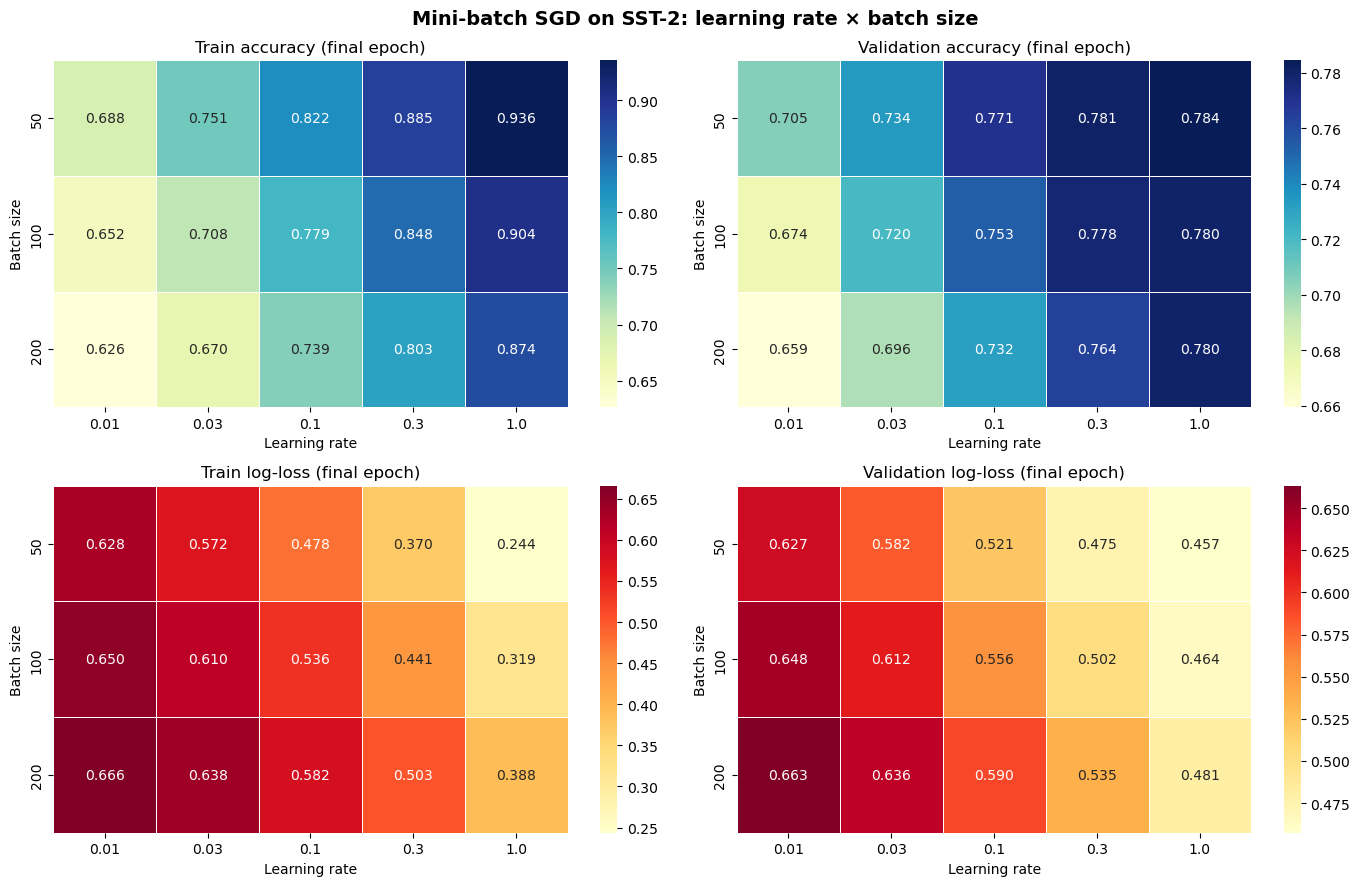

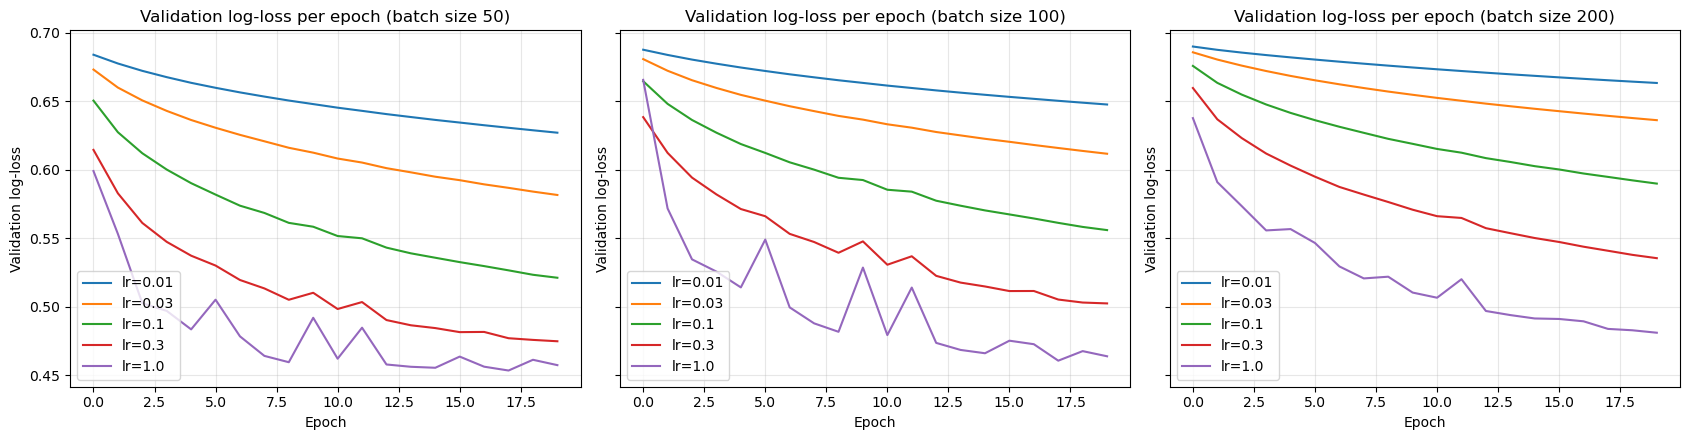

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
panels = [("train_acc", "Train accuracy (final epoch)", "YlGnBu"), ("val_acc", "Validation accuracy (final epoch)", "YlGnBu"),
          ("train_loss", "Train log-loss (final epoch)", "YlOrRd"), ("val_loss", "Validation log-loss (final epoch)", "YlOrRd")]
for ax, (key, title, cmap) in zip(axes.ravel(), panels):
    sns.heatmap(grid[key], annot=True, fmt=".3f", cmap=cmap, ax=ax, linewidths=0.5,
                xticklabels=learning_rates, yticklabels=batch_sizes)
    ax.set(title=title, xlabel="Learning rate", ylabel="Batch size")
fig.suptitle("Mini-batch SGD on SST-2: learning rate × batch size", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
for ax, bs in zip(axes, batch_sizes):
    for lr in learning_rates:
        ax.plot([r["val_loss"] for r in curves[(bs, lr)]], label=f"lr={lr}")
    ax.set(title=f"Validation log-loss per epoch (batch size {bs})", xlabel="Epoch", ylabel="Validation log-loss")
    ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

### Analysis: learning rate and batch size

**Convergence speed.** Within the 20-epoch budget, a **larger learning rate is better at every batch size**:
- Validation accuracy climbs from 0.66–0.71 at lr = 0.01 to about 0.78 at lr = 1.0.
- At lr = 0.01 the model is nowhere near converged. Validation loss ends at 0.63–0.66, barely below the uninformed ln 2 ≈ 0.693.
- The loss is convex and the gradients of sparse count features are small, so lr = 1.0 is not "too large" here. It is simply the only rate that finishes most of the optimisation in 20 epochs.

**Stability.** The validation-loss curves show the cost of large steps. For lr ≤ 0.3 they decrease smoothly. At lr = 1.0 they spike repeatedly (for example at epochs 5, 9 and 11 for batch size 100). The noise shrinks as the batch grows, because larger batches average out gradient noise.

**Batch size.** At a fixed learning rate and number of epochs, **smaller batches do better** (50 > 100 > 200). The reason is that they make more parameter updates per epoch: 139 vs 70 vs 35. Batch size and learning rate trade off: batch 200 at lr = 0.3 (0.764) roughly matches batch 100 at lr 0.1–0.3.

**Final performance and overfitting.** Validation accuracy **plateaus at about 0.78** for all the fast configurations, while training accuracy keeps rising (up to 0.936 at batch 50, lr = 1.0). That 15-point gap is the model starting to memorise rare words. It is the ceiling of a linear bag-of-words model, and closing the gap would need regularisation, early stopping or richer features rather than more optimisation.

**Choice:** batch 50 at lr = 0.3 (val 0.781) gets within 0.3 points of the best run (lr = 1.0, 0.784) with a much smoother, more predictable loss curve.

## 5. L1 regularisation and sparsity

Three questions:
1. **Initialisation.** With an L1 penalty, do zero and small-random initialisations differ in stability, accuracy or sparsity?
2. **Strength of λ.** How do accuracy and the number of non-zero weights change for λ ∈ {0, 1e-4, 1e-3, 1e-2, 1e-1}, at lr = 0.1 and batch size 100?
3. **Subgradient vs. proximal.** Does plain SGD on the L1-penalised loss actually zero out weights, or does it take a soft-thresholding (proximal) step to get exact zeros?

We count weights with |w| ≥ 1e-7 as "non-zero", and also report |w| ≥ 1e-3 to capture weights that are *effectively* zero.

Initialisation comparison (L1, lambda=1e-3, lr=0.1, batch 100)


   zeros: NaN=False | train acc 0.6893 | val acc 0.7133 | {'nonzero_1e-7': 9992, 'nonzero_1e-3': 562}


  random: NaN=False | train acc 0.6897 | val acc 0.7122 | {'nonzero_1e-7': 9984, 'nonzero_1e-3': 552}


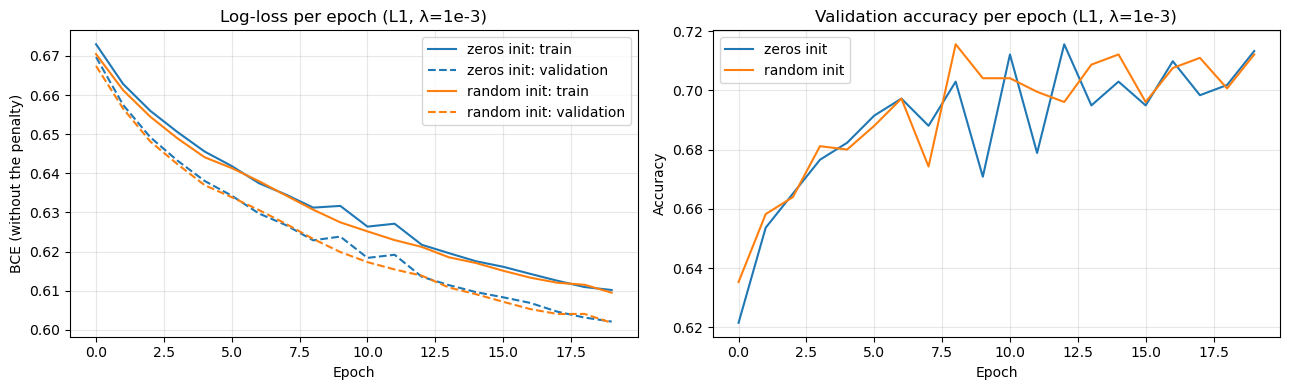

In [9]:
def sparsity_report(w):
    return {"nonzero_1e-7": int((np.abs(w) >= 1e-7).sum()), "nonzero_1e-3": int((np.abs(w) >= 1e-3).sum())}

print("Initialisation comparison (L1, lambda=1e-3, lr=0.1, batch 100)")
init_logs = {}
for init in ["zeros", "random"]:
    w, _, _, log = sgd_logistic_regression(X_train, y_train, X_val, y_val, lr=0.1, batch_size=100,
                                           init=init, penalty="l1", reg_lambda=1e-3)
    init_logs[init] = log
    print(f"  {init:>6}: NaN={np.isnan(w).any()} | train acc {log[-1]['train_metric']:.4f}"
          f" | val acc {log[-1]['val_metric']:.4f} | {sparsity_report(w)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for init, color in [("zeros", "tab:blue"), ("random", "tab:orange")]:
    log = init_logs[init]
    axes[0].plot([r["train_loss"] for r in log], color=color, label=f"{init} init: train")
    axes[0].plot([r["val_loss"] for r in log], color=color, ls="--", label=f"{init} init: validation")
    axes[1].plot([r["val_metric"] for r in log], color=color, label=f"{init} init")
axes[0].set(title="Log-loss per epoch (L1, λ=1e-3)", xlabel="Epoch", ylabel="BCE (without the penalty)")
axes[1].set(title="Validation accuracy per epoch (L1, λ=1e-3)", xlabel="Epoch", ylabel="Accuracy")
for ax in axes: ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

In [10]:
lambdas = [0, 1e-4, 1e-3, 1e-2, 1e-1]
lam_res = {"l1": [], "l1_prox": []}
for method in lam_res:
    for lam in lambdas:
        w, _, hist, log = sgd_logistic_regression(X_train, y_train, X_val, y_val, lr=0.1, batch_size=100,
                                                  penalty=method, reg_lambda=lam, track_history=(lam == 1e-2))
        r = {"lambda": lam, "w": w, "hist": hist, "train_acc": log[-1]["train_metric"],
             "val_acc": log[-1]["val_metric"], **sparsity_report(w)}
        lam_res[method].append(r)
        print(f"{method:>7} λ={lam:<6} | train acc {r['train_acc']:.4f} | val acc {r['val_acc']:.4f}"
              f" | non-zero (≥1e-7) {r['nonzero_1e-7']:5d} | non-zero (≥1e-3) {r['nonzero_1e-3']:5d}")

     l1 λ=0      | train acc 0.7793 | val acc 0.7534 | non-zero (≥1e-7) 10000 | non-zero (≥1e-3)  9697


     l1 λ=0.0001 | train acc 0.7577 | val acc 0.7420 | non-zero (≥1e-7)  9976 | non-zero (≥1e-3)  4625


     l1 λ=0.001  | train acc 0.6893 | val acc 0.7133 | non-zero (≥1e-7)  9992 | non-zero (≥1e-3)   562


     l1 λ=0.01   | train acc 0.5699 | val acc 0.5986 | non-zero (≥1e-7)  9998 | non-zero (≥1e-3)   243


     l1 λ=0.1    | train acc 0.5186 | val acc 0.4977 | non-zero (≥1e-7) 10000 | non-zero (≥1e-3)  7534


l1_prox λ=0      | train acc 0.7793 | val acc 0.7534 | non-zero (≥1e-7) 10000 | non-zero (≥1e-3)  9697


l1_prox λ=0.0001 | train acc 0.7577 | val acc 0.7420 | non-zero (≥1e-7)  8232 | non-zero (≥1e-3)  4615


l1_prox λ=0.001  | train acc 0.6895 | val acc 0.7133 | non-zero (≥1e-7)  2075 | non-zero (≥1e-3)   540


l1_prox λ=0.01   | train acc 0.5699 | val acc 0.5975 | non-zero (≥1e-7)   241 | non-zero (≥1e-3)   224


l1_prox λ=0.1    | train acc 0.5217 | val acc 0.5092 | non-zero (≥1e-7)     4 | non-zero (≥1e-3)     3


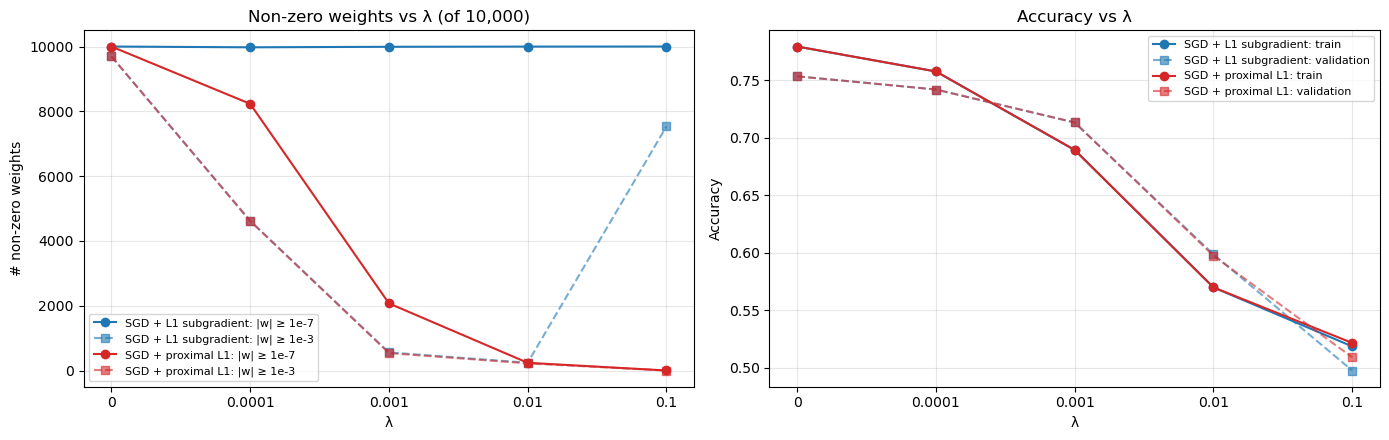

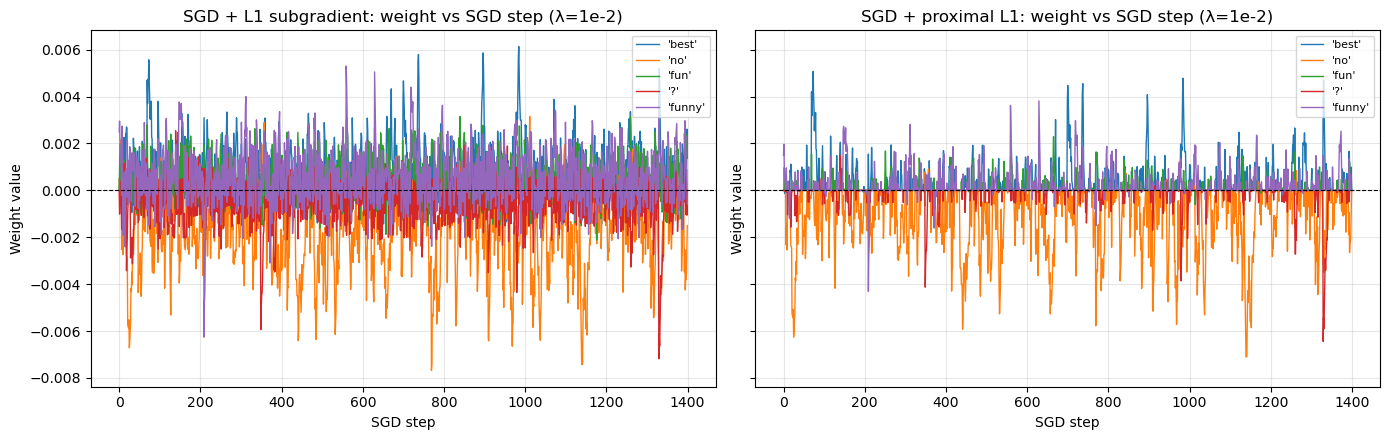

In [11]:
x = np.arange(len(lambdas)); labels = [str(l) for l in lambdas]
styles = {"l1": ("SGD + L1 subgradient", "tab:blue"), "l1_prox": ("SGD + proximal L1", "tab:red")}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for m, (name, c) in styles.items():
    axes[0].plot(x, [r["nonzero_1e-7"] for r in lam_res[m]], "o-", color=c, label=f"{name}: |w| ≥ 1e-7")
    axes[0].plot(x, [r["nonzero_1e-3"] for r in lam_res[m]], "s--", color=c, alpha=0.6, label=f"{name}: |w| ≥ 1e-3")
    axes[1].plot(x, [r["train_acc"] for r in lam_res[m]], "o-", color=c, label=f"{name}: train")
    axes[1].plot(x, [r["val_acc"] for r in lam_res[m]], "s--", color=c, alpha=0.6, label=f"{name}: validation")
axes[0].set(title="Non-zero weights vs λ (of 10,000)", xlabel="λ", ylabel="# non-zero weights")
axes[1].set(title="Accuracy vs λ", xlabel="λ", ylabel="Accuracy")
for ax in axes: ax.set_xticks(x, labels); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Weight dynamics at λ = 1e-2: features that the proximal method eliminates (exactly 0 at the end)
# but that carry signal without regularisation. Compare their paths under both methods.
i_lam = lambdas.index(1e-2)
w_free = lam_res["l1"][0]["w"]
w_prox = lam_res["l1_prox"][i_lam]["w"]
candidates = np.where(w_prox == 0)[0]
feats = candidates[np.argsort(-np.abs(w_free[candidates]))][:5]
inv_vocab = {i: t for t, i in vocab.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, m in zip(axes, ["l1", "l1_prox"]):
    hist = lam_res[m][i_lam]["hist"]
    for f in feats:
        ax.plot(hist[:, f], lw=1, label=f"'{inv_vocab[f]}'")
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set(title=f"{styles[m][0]}: weight vs SGD step (λ=1e-2)", xlabel="SGD step", ylabel="Weight value")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Analysis: L1 regularisation

**Initialisation.** Zero and small-random initialisation are practically identical: validation accuracy is 0.7133 vs 0.7122, with no NaNs in either run and the same sparsity. Logistic regression is convex, so there is no symmetry to break and no bad basin to fall into. Initialisation matters little as long as the random scale is small.

**Accuracy vs λ.** Validation accuracy **decreases monotonically** as λ grows: 0.753 → 0.742 → 0.713 → 0.599 → 0.498.
- At lr = 0.1 for 20 epochs, the unregularised model is barely overfitting (train 0.78 vs val 0.75). So L1 has little variance to remove and mostly adds bias.
- At λ ≥ 1e-2 the model collapses to chance. Most words appear in only a few sentences, so their data gradient in any batch is tiny, and a constant penalty of λ per weight overwhelms it.

**Sparsity: subgradient SGD does not produce zeros.** With the plain L1 subgradient, **at least 9,976 of the 10,000 weights stay above 1e-7 at every λ**.
- The weights do shrink: at λ = 1e-3 only 562 remain above 1e-3.
- But the update w ← w − αλ·sign(w) overshoots zero and **oscillates around it with amplitude ≈ αλ**.
- At λ = 0.1 that amplitude is 0.01, so 7,534 weights sit above 1e-3. A *stronger* penalty looks *less* sparse, which is a direct symptom of the subgradient step.

**The proximal step fixes this.** Soft-thresholding, w ← sign(w)·max(|w| − αλ, 0), sets weights to exactly 0 and keeps them there unless the data gradient pushes hard enough.
- The number of non-zero weights falls from 8,232 to 2,075, then 241, then 4 as λ grows.
- Accuracy is the same as the subgradient version at each λ.
- At λ = 1e-3 this **removes 79% of the vocabulary**. The result is a model that uses about 2,000 words, at a cost of 4 points of validation accuracy.

**Weight dynamics.** The trajectories at λ = 1e-2 show the difference.
- *Subgradient:* the eliminated weights jitter around zero indefinitely.
- *Proximal:* they spend most steps at exactly 0 and only leave briefly when a batch contains the word.

The eliminated words include *best*, *fun*, *funny* and *no*, which are strong sentiment signals. That is a sign λ = 1e-2 is too strong for this problem.

## 6. Optimizers from scratch: convex bowl vs. Six-hump Camel

GD, Momentum, AdaGrad and Adam are implemented as small update rules that plug into one shared runner. The runner handles the loss, backward pass, gradient reset and trajectory logging, which removes the four near-identical loops.

- **Convex bowl:** $f(x,y) = x^2 + 4y^2$. One global minimum at (0, 0). It is anisotropic: the curvature along *y* is 4× that along *x*.
- **Six-hump Camel:** $f(x,y) = (4 - 2.1x^2 + x^4/3)x^2 + xy + (-4 + 4y^2)y^2$. Two global minima, at (±0.0898, ∓0.7126) with f ≈ −1.0316, plus four local minima.

In [12]:
def bowl(t):  return t[0] ** 2 + 4 * t[1] ** 2
def camel(t): return (4 - 2.1 * t[0] ** 2 + t[0] ** 4 / 3) * t[0] ** 2 + t[0] * t[1] + (-4 + 4 * t[1] ** 2) * t[1] ** 2

def run(f, theta0, update, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    state, traj, vals = {}, [theta.detach().clone()], [f(theta).item()]
    for step in range(1, n_steps + 1):
        f(theta).backward()
        with torch.no_grad():
            update(theta, theta.grad, step, state)
        theta.grad.zero_()
        traj.append(theta.detach().clone()); vals.append(f(theta).item())
    return torch.stack(traj).numpy(), np.array(vals)

def gd(lr):
    def u(t, g, s, st): t -= lr * g
    return u

def momentum(lr, beta=0.9):
    def u(t, g, s, st):
        st["v"] = beta * st.get("v", torch.zeros_like(t)) + g
        t -= lr * st["v"]
    return u

def adagrad(lr, eps=1e-8):
    def u(t, g, s, st):
        st["G"] = st.get("G", torch.zeros_like(t)) + g ** 2
        t -= lr * g / (st["G"].sqrt() + eps)
    return u

def adam(lr, b1=0.9, b2=0.999, eps=1e-8):
    def u(t, g, s, st):
        st["m"] = b1 * st.get("m", torch.zeros_like(t)) + (1 - b1) * g
        st["v"] = b2 * st.get("v", torch.zeros_like(t)) + (1 - b2) * g ** 2
        m_hat, v_hat = st["m"] / (1 - b1 ** s), st["v"] / (1 - b2 ** s)
        t -= lr * m_hat / (v_hat.sqrt() + eps)
    return u

CONFIGS = {  # the same hyperparameters are used on both functions
    "GD":       gd(0.02),
    "Momentum": momentum(0.01, 0.9),
    "AdaGrad":  adagrad(0.3),
    "Adam":     adam(0.05),
}
COLORS = {"GD": "tab:blue", "Momentum": "tab:orange", "AdaGrad": "tab:green", "Adam": "tab:red"}
START = (-2.0, -1.5)

results = {fname: {name: run(f, START, upd) for name, upd in CONFIGS.items()}
           for fname, f in [("bowl", bowl), ("camel", camel)]}

def steps_to(vals, target, tol):
    hit = np.where(np.abs(vals - target) < tol)[0]
    return int(hit[0]) if len(hit) else None

for fname, target in [("bowl", 0.0), ("camel", -1.0316)]:
    print(f"\n{fname} (start {START}, target f = {target})")
    for name, (traj, vals) in results[fname].items():
        print(f"  {name:>8}: final f = {vals[-1]: .5f} at ({traj[-1, 0]: .4f}, {traj[-1, 1]: .4f})"
              f" | steps until |f - f_final| < 1e-4: {steps_to(vals, vals[-1], 1e-4)}")


bowl (start (-2.0, -1.5), target f = 0.0)
        GD: final f =  0.00000 at (-0.0000, -0.0000) | steps until |f - f_final| < 1e-4: 130
  Momentum: final f =  0.00000 at (-0.0000,  0.0000) | steps until |f - f_final| < 1e-4: 82
   AdaGrad: final f =  0.00000 at (-0.0000, -0.0000) | steps until |f - f_final| < 1e-4: 75
      Adam: final f =  0.00000 at (-0.0000, -0.0000) | steps until |f - f_final| < 1e-4: 107

camel (start (-2.0, -1.5), target f = -1.0316)
        GD: final f =  2.10425 at (-1.6071, -0.5687) | steps until |f - f_final| < 1e-4: 15
  Momentum: final f = -1.03163 at ( 0.0898, -0.7127) | steps until |f - f_final| < 1e-4: 85
   AdaGrad: final f =  2.10425 at (-1.6071, -0.5687) | steps until |f - f_final| < 1e-4: 82
      Adam: final f =  2.10425 at (-1.6071, -0.5687) | steps until |f - f_final| < 1e-4: 111


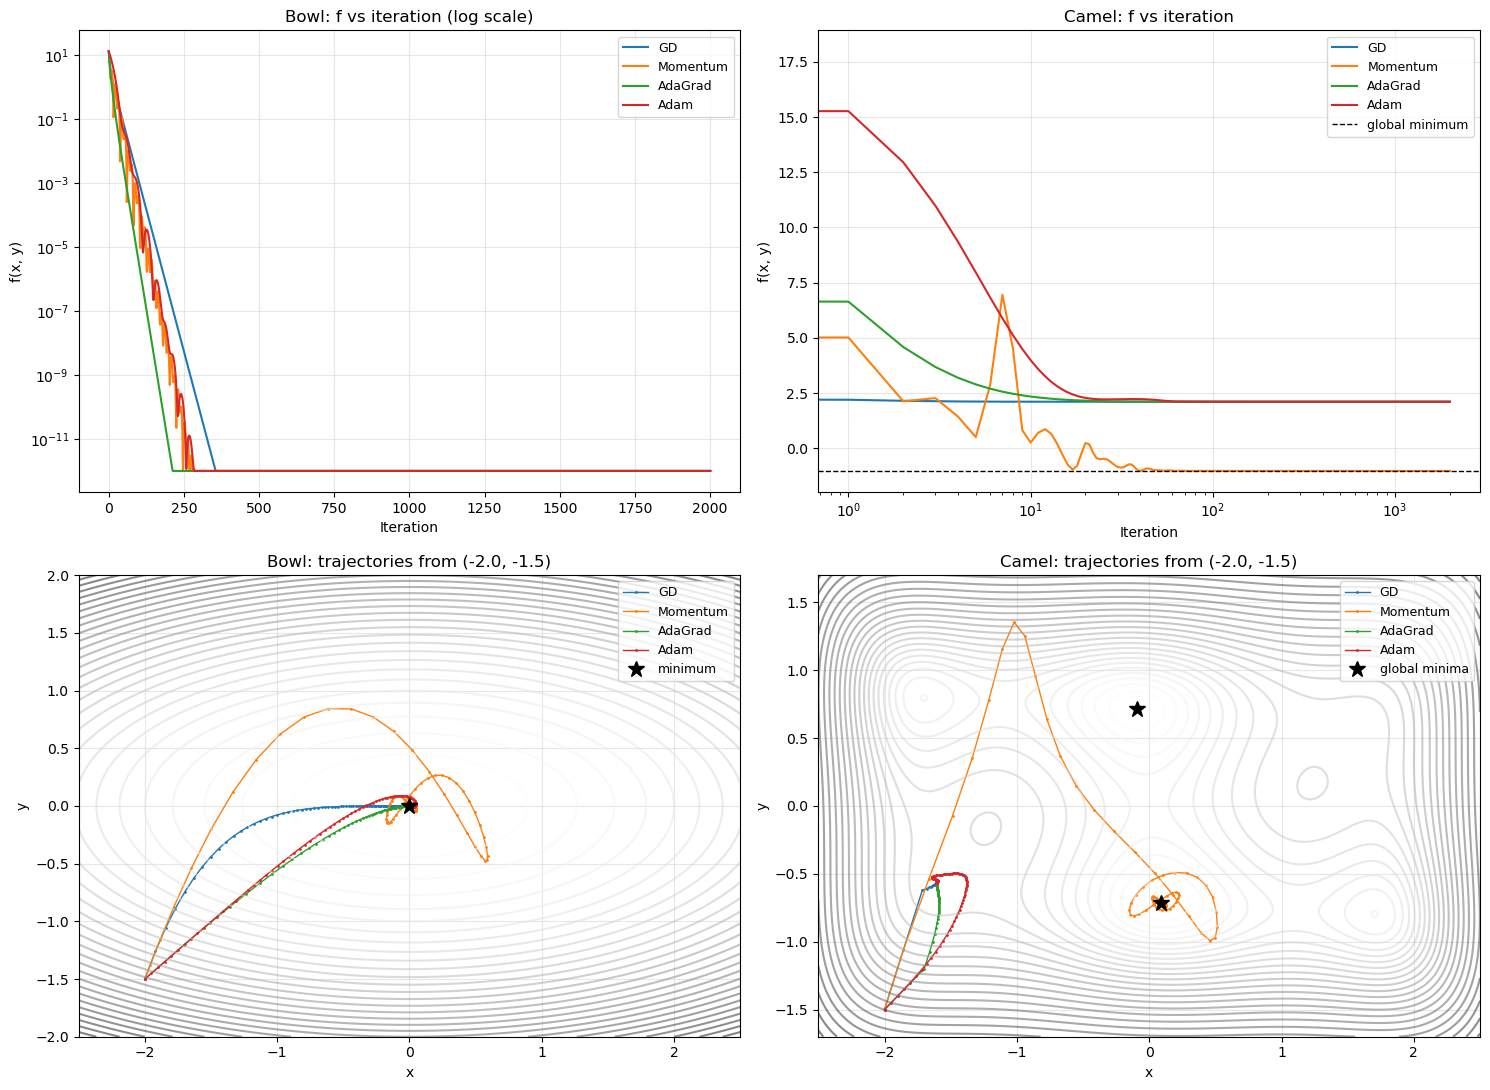

In [13]:
def contour(ax, f, xlim, ylim, log_shift=None):
    X, Y = np.meshgrid(np.linspace(*xlim, 300), np.linspace(*ylim, 300))
    Z = f(torch.tensor(np.stack([X, Y]), dtype=torch.float32)).numpy()
    ax.contour(X, Y, np.log1p(Z - Z.min()) if log_shift else Z, levels=30, cmap="Greys", alpha=0.5)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for name, (traj, vals) in results["bowl"].items():
    axes[0, 0].semilogy(np.maximum(vals, 1e-12), color=COLORS[name], label=name)
    axes[1, 0].plot(traj[:, 0], traj[:, 1], ".-", ms=2, lw=1, color=COLORS[name], label=name)
for name, (traj, vals) in results["camel"].items():
    axes[0, 1].plot(vals, color=COLORS[name], label=name)
    axes[1, 1].plot(traj[:, 0], traj[:, 1], ".-", ms=2, lw=1, color=COLORS[name], label=name)
axes[0, 1].axhline(-1.0316, color="black", ls="--", lw=1, label="global minimum")
contour(axes[1, 0], bowl, (-2.5, 2.5), (-2, 2))
contour(axes[1, 1], camel, (-2.5, 2.5), (-1.7, 1.7), log_shift=True)
axes[1, 0].plot(0, 0, "k*", ms=12, label="minimum")
axes[1, 1].plot([0.0898, -0.0898], [-0.7126, 0.7126], "k*", ms=12, label="global minima")
axes[0, 0].set(title="Bowl: f vs iteration (log scale)", xlabel="Iteration", ylabel="f(x, y)")
axes[0, 1].set(title="Camel: f vs iteration", xlabel="Iteration", ylabel="f(x, y)", xscale="log")
axes[1, 0].set(title=f"Bowl: trajectories from {START}", xlabel="x", ylabel="y")
axes[1, 1].set(title=f"Camel: trajectories from {START}", xlabel="x", ylabel="y", xlim=(-2.5, 2.5), ylim=(-1.7, 1.7))
for ax in axes.ravel(): ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Does the result depend on the starting point?** A single start can't say whether an optimizer "finds the global minimum". So we run every optimizer from a 7 × 5 grid of starting points on the Camel function and count how often each one reaches a global minimum (f < −1.03).

      GD: global min reached from 57.1% of 35 starts | distinct end values: [-1.032, -0.215, 0.0, 2.104]


Momentum: global min reached from 62.9% of 35 starts | distinct end values: [-1.032, -0.215, 0.0, 2.104]


 AdaGrad: global min reached from 45.7% of 35 starts | distinct end values: [-1.032, -0.215, 0.0, 2.104]


    Adam: global min reached from 40.0% of 35 starts | distinct end values: [-1.032, -0.215, 0.0, 2.104]


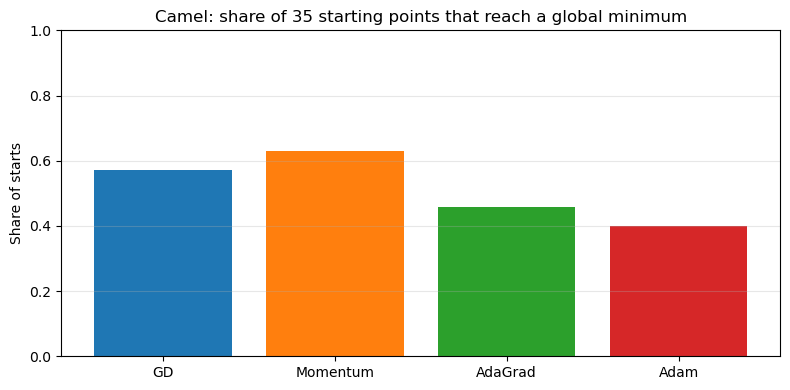

In [14]:
starts = [(x0, y0) for x0 in np.linspace(-2.4, 2.4, 7) for y0 in np.linspace(-1.2, 1.2, 5)]
summary = {}
for name, upd in CONFIGS.items():
    finals = np.array([run(camel, s, upd, n_steps=1500)[1][-1] for s in starts])
    finals = finals[np.isfinite(finals)]
    summary[name] = finals
    print(f"{name:>8}: global min reached from {np.mean(finals < -1.03):5.1%} of {len(starts)} starts"
          f" | distinct end values: {sorted(set(np.round(finals, 3)))}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(list(summary), [np.mean(v < -1.03) for v in summary.values()], color=[COLORS[n] for n in summary])
ax.set(title="Camel: share of 35 starting points that reach a global minimum", ylabel="Share of starts", ylim=(0, 1))
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

### Analysis: optimizers

**Convex bowl.** All four optimizers reach (0, 0) to machine precision. The steps needed to get within 1e-4 of the minimum were: AdaGrad 75, Momentum 82, Adam 107, GD 130.
- **GD** follows a bent path. It first descends the steep *y*-direction, then crawls along the shallow *x*-direction. This is ill-conditioning: the curvature ratio is 4.
- **AdaGrad and Adam** rescale each coordinate by its gradient history, which cancels the anisotropy, so they head almost straight to the minimum.
- **Momentum** overshoots widely (to *y* ≈ 0.85 and then *x* ≈ 0.6) but still arrives quickly, because its velocity builds up along the shallow direction.

**Six-hump Camel from (−2, −1.5).**
- GD, AdaGrad and Adam all settle in the **same local minimum**, f = 2.104 at (−1.607, −0.569), the basin they start in.
- Only **Momentum** reaches the global minimum, f = −1.0316 at (0.0898, −0.7127). Its accumulated velocity carries it uphill over the ridge: its f(x, y) curve spikes to about 7 at iteration 7 before descending.

**Multi-start test: no optimizer is reliable.** Across 35 starting points, the share that reached a global minimum was:

| Momentum | GD | AdaGrad | Adam |
|---|---|---|---|
| 62.9% | 57.1% | 45.7% | 40.0% |

Every run ends at one of the same four values:
- −1.032 (the global minima)
- −0.215 and 2.104 (local minima)
- 0.0, the **saddle point at the origin**. It is in the start grid, and since the gradient there is exactly zero, no first-order method can move away from it.

Which minimum a run reaches depends far more on **which basin it starts in** than on the optimizer.

**Hyperparameter transfer.** The same settings were used on both functions. They are all fast on the bowl, but on the Camel function the adaptive methods take cautious, normalised steps of about `lr` each and stay in their starting basin. Adam's strength is robustness to gradient scale, not global exploration. It came *last* in the multi-start test.

**What each method adds over GD:**
- *Momentum* speeds up progress along shallow directions and can jump out of shallow basins, though unpredictably.
- *AdaGrad* rescales each coordinate, which fixes ill-conditioning, but its step size only ever shrinks.
- *Adam* combines both with bias correction, which makes it the most tuning-robust default for training models.

None of them gives global guarantees on a non-convex surface. That needs restarts, better initialisation or stochasticity.

## 7. Summary

| Topic | Finding |
|---|---|
| Numerical stability | Clamping only works if ε is representable: in float32, `1 − 1e-15 == 1.0`. Using ε = 1e-7 keeps saturated predictions finite (loss 16.03 instead of `NaN`). |
| Learning rate × batch size | In a 20-epoch budget, larger learning rates and smaller batches converge faster. Validation accuracy plateaus at **~0.78**, while training accuracy reaches 0.94, so this is the ceiling of a linear bag-of-words model. |
| L1 with subgradient SGD | Shrinks weights but produces almost **no exact zeros**: they oscillate around 0 with amplitude ≈ αλ. |
| L1 with a proximal step | Gives **true sparsity** at the same accuracy: 79% of features removed at λ = 1e-3, for −4 points of validation accuracy. |
| Optimizers | Adaptive methods fix ill-conditioning on the convex bowl. On the Camel function, the **starting basin** decides the outcome: the best method reaches the global minimum from only 63% of starts. |